# 04 - Pengujian End-to-End Sistem per Format Input

Notebook ini menguji **pipeline lengkap** sistem peringkasan rapat secara end-to-end:

```
Input File → Transkripsi (Whisper) → Filter Kata Kasar → Peringkasan (IndoT5) → Evaluasi ROUGE
```

Pengujian dipisahkan berdasarkan **format input** (MP4, MP3, WAV) untuk membandingkan:
1. **Waktu proses** di setiap tahap pipeline
2. **Skor ROUGE** hasil ringkasan per format
3. **Konsistensi output** antar format input

In [1]:
import os
os.chdir('..')
print(os.getcwd())

import pandas as pd
from pathlib import Path

NAMA_DOKUMEN = 'Paripurna_Ke_20_Persidangan_IV_2024_2025'

df = pd.read_csv('dataset/data_segment_corrected_ocr.csv')
df_dok = df[df['dokumen_asal'] == NAMA_DOKUMEN].copy()
df_dok['target_summary_manual'] = df_dok['target_summary_manual'].fillna('').astype(str)

# Gabungkan 3 segmen jadi 1 referensi per dokumen
referensi = ' '.join(df_dok['target_summary_manual'].tolist())
jumlah_segmen = len(df_dok)

df_e2e_ref = pd.DataFrame([{
    'dokumen_asal'       : NAMA_DOKUMEN,
    'referensi_ringkasan': referensi,
    'jumlah_segmen'      : jumlah_segmen,
}])

out_path = Path('dataset/end_to_end_test_reference.csv')
df_e2e_ref.to_csv(out_path, index=False, encoding='utf-8')

print(f"Referensi dibuat dari {jumlah_segmen} segmen dokumen {NAMA_DOKUMEN}")
display(df_e2e_ref)

d:\Skripsi\meeting-summarizer
Referensi dibuat dari 3 segmen dokumen Paripurna_Ke_20_Persidangan_IV_2024_2025


,dokumen_asal,referensi_ringkasan,jumlah_segmen
0,Paripurna_Ke_20_Persidangan_IV_2024_2025,Rapat Paripurna DPR RI membuka Masa Persidanga...,3


## 1. Import & Setup

In [2]:
import os
import sys
import time
import pandas as pd
import evaluate
import torch
import matplotlib.pyplot as plt
from pathlib import Path

ffmpeg_dir = r"C:\Users\User\AppData\Local\Microsoft\WinGet\Packages"
for root, dirs, files in os.walk(ffmpeg_dir):
    if "ffmpeg.exe" in files:
        os.environ["PATH"] = root + ";" + os.environ["PATH"]
        print(f"FFmpeg ditemukan: {root}")
        break

sys.path.append('..')
from modules.transcriber import transcribe_audio, WHISPER_MODEL, WHISPER_LANGUAGE
from modules.filter_kata import filter_teks
from modules.summarizer import summarize_text

print(f"Whisper model: {WHISPER_MODEL}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FFmpeg ditemukan: C:\Users\User\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.0.1-full_build\bin
Whisper model: medium
Device: cpu


## 2. Konfigurasi File Uji

Menggunakan file referensi khusus end-to-end (`end_to_end_test_reference.csv`) yang berisi ringkasan gabungan per dokumen utuh.

In [3]:
df_ref = pd.read_csv('dataset/end_to_end_test_reference.csv')

SAMPLE_FILES = ['Paripurna_Ke_20_Persidangan_IV_2024_2025']

print(f"Referensi end-to-end di CSV: {len(df_ref)} dokumen")
print(f"SEDANG MENGUJI {len(SAMPLE_FILES)} FILE")

# Filter tabel untuk ditampilin
df_tampil = df_ref[df_ref['dokumen_asal'].isin(SAMPLE_FILES)]
display(df_tampil[['dokumen_asal', 'jumlah_segmen']])

# Direktori sumber
DIR_MP4 = Path('dataset/01_raw/video_mp4')
DIR_MP3 = Path('dataset/01_raw/audio_mp3')
DIR_WAV = Path('dataset/01_raw/audio_wav')

# Format dan direktori
FORMAT_MAP = {
    'MP4': (DIR_MP4, '.mp4'),
    'MP3': (DIR_MP3, '.mp3'),
    'WAV': (DIR_WAV, '.wav'),
}

# Validasi keberadaan file
print("\nValidasi file uji:")
for name in SAMPLE_FILES:
    for fmt, (dir_path, ext) in FORMAT_MAP.items():
        fp = dir_path / (name + ext)
        status = '✅' if fp.exists() else '❌'
        print(f"  {status} {fmt}: {fp.name}")

Referensi end-to-end di CSV: 1 dokumen
SEDANG MENGUJI 1 FILE


,dokumen_asal,jumlah_segmen
0,Paripurna_Ke_20_Persidangan_IV_2024_2025,3



Validasi file uji:
  ✅ MP4: Paripurna_Ke_20_Persidangan_IV_2024_2025.mp4
  ✅ MP3: Paripurna_Ke_20_Persidangan_IV_2024_2025.mp3
  ✅ WAV: Paripurna_Ke_20_Persidangan_IV_2024_2025.wav


## 3. Fungsi Pipeline End-to-End

Menjalankan seluruh tahapan dan mencatat waktu per tahap.

In [4]:
def pipeline_end_to_end(file_path: Path, fmt_label: str) -> dict:
    """
    Jalankan pipeline lengkap untuk satu file:
      1. Transkripsi (Whisper)
      2. Filter kata kasar
      3. Peringkasan (IndoT5)
    """
    hasil = {
        'file': file_path.stem,
        'format': fmt_label,
    }
    
    # ── Tahap 1: Transkripsi Whisper ──
    print(f"Tahap 1: Transkripsi Whisper...")
    t0 = time.time()
    teks_transkrip = transcribe_audio(
        file_path,
        model_name=WHISPER_MODEL,
        language=WHISPER_LANGUAGE,
    )
    hasil['waktu_transkripsi'] = round(time.time() - t0, 2)
    hasil['jumlah_kata_transkrip'] = len(teks_transkrip.split())
    print(f"      {hasil['waktu_transkripsi']}s | {hasil['jumlah_kata_transkrip']} kata")
    
    # ── Tahap 2: Filter Kata Kasar ──
    print(f"Tahap 2: Filter kata kasar...")
    t0 = time.time()
    teks_bersih = filter_teks(teks_transkrip, hapus=True)
    hasil['waktu_filter'] = round(time.time() - t0, 4)
    hasil['jumlah_kata_bersih'] = len(teks_bersih.split())
    kata_difilter = hasil['jumlah_kata_transkrip'] - hasil['jumlah_kata_bersih']
    print(f"      {hasil['waktu_filter']}s | {kata_difilter} kata difilter")
    
    # ── Tahap 3: Peringkasan IndoT5 ──
    print(f"Tahap 3: Peringkasan IndoT5...")
    t0 = time.time()
    ringkasan = summarize_text(teks_bersih)
    hasil['waktu_ringkasan'] = round(time.time() - t0, 2)
    hasil['jumlah_kata_ringkasan'] = len(ringkasan.split())
    print(f"      {hasil['waktu_ringkasan']}s | {hasil['jumlah_kata_ringkasan']} kata ringkasan")
    
    # ── Total ──
    hasil['waktu_total'] = round(
        hasil['waktu_transkripsi'] + hasil['waktu_filter'] + hasil['waktu_ringkasan'], 2
    )
    hasil['teks_transkrip'] = teks_transkrip
    hasil['teks_bersih'] = teks_bersih
    hasil['ringkasan'] = ringkasan
    
    return hasil

print("Fungsi pipeline_end_to_end siap.")

Fungsi pipeline_end_to_end siap.


## 4. Jalankan Pengujian End-to-End

Pipeline dijalankan untuk setiap file uji × setiap format input.

In [5]:
semua_hasil = []

total_tes = len(SAMPLE_FILES) * len(FORMAT_MAP)
counter = 0

for name in SAMPLE_FILES:
    print(f"\n{'='*60}")
    print(f"FILE: {name}")
    print(f"{'='*60}")
    
    for fmt_label, (dir_path, ext) in FORMAT_MAP.items():
        counter += 1
        file_path = dir_path / (name + ext)
        
        if not file_path.exists():
            print(f"\n  [{counter}/{total_tes}] {fmt_label}: File tidak ditemukan, SKIP")
            continue
        
        print(f"\n  [{counter}/{total_tes}] Format: {fmt_label}")
        
        try:
            hasil = pipeline_end_to_end(file_path, fmt_label)
            semua_hasil.append(hasil)
            print(f"    Total Waktu: {hasil['waktu_total']}s")
        except Exception as e:
            print(f"    ERROR: {e}")

print(f"\n\n{'='*60}")
print(f"Selesai! {len(semua_hasil)}/{total_tes} pengujian berhasil.")
print(f"{'='*60}")


FILE: Paripurna_Ke_20_Persidangan_IV_2024_2025

  [1/3] Format: MP4
Tahap 1: Transkripsi Whisper...


d:\Skripsi\meeting-summarizer\venv\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")
100%|██████████| 65204/65204 [09:29<00:00, 114.48frames/s]


      582.48s | 1039 kata
Tahap 2: Filter kata kasar...
      0.0023s | 0 kata difilter
Tahap 3: Peringkasan IndoT5...


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 488.12it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


      24.02s | 140 kata ringkasan
    Total Waktu: 606.5s

  [2/3] Format: MP3
Tahap 1: Transkripsi Whisper...


100%|██████████| 65200/65200 [09:14<00:00, 117.64frames/s]


      555.18s | 1038 kata
Tahap 2: Filter kata kasar...
      0.0008s | 0 kata difilter
Tahap 3: Peringkasan IndoT5...
      19.98s | 140 kata ringkasan
    Total Waktu: 575.16s

  [3/3] Format: WAV
Tahap 1: Transkripsi Whisper...


100%|██████████| 65200/65200 [09:11<00:00, 118.16frames/s]


      552.19s | 1038 kata
Tahap 2: Filter kata kasar...
      0.0013s | 0 kata difilter
Tahap 3: Peringkasan IndoT5...
      18.74s | 129 kata ringkasan
    Total Waktu: 570.93s


Selesai! 3/3 pengujian berhasil.


In [6]:
for h in semua_hasil:
    print(f"FORMAT: {h['format']}")
    print(f"RINGKASAN: {h['ringkasan']}")
    print(f"TEKS BERSIH (input summarizer): {h['teks_bersih'][:200]}")
    print()

FORMAT: MP4
RINGKASAN: DPR RI menyampaikan laporan tentang pidato Ketua DPR RI pada pembukaan masa persidangan 4 tahun sidang 2024-2025. Anggota DPR menyatakan bahwa pembangunan nasional juga memberikan pelayanan untuk rakyat. Pemerintah telah melakukan tugas dan fungsi konstitusional, yang akan meningkatkan kehidupan masyarakat. DPR RI dapat mengapresiasi acara Rapat Paripurna. . DPR RI akan membahas 8 rancangan undang-undang, dan 5 Rancangan Undang-Undang tentang pertanggungjawaban atas pelaksanaan APBN tahun anggaran 2024. Anggota DPR menyampaikan apresiasi terhadap kebijakan pemerintah yang responsif untuk mengatasi permasalahan ekonomi global. Pemerintah juga telah melakukan pembahasan pada efektivitas pencapaian dan efisiensi kegiatan. . DPR RI akan melakukan pembahasan tentang pemberian perundang-Undang dan kebijakan ekonomi untuk meningkatkan kesejahteraan rakyat. Anggota DPR menyampaikan aspirasi atas permasalahan dalam pelaksanaan ibadah haji 2024-2025. DPRRI juga telah mener

## 5. Tabel Perbandingan Waktu per Tahap dan Format

In [7]:
# Buat DataFrame hasil
df_hasil = pd.DataFrame(semua_hasil)

# Tabel detail per file
kolom_tampil = ['file', 'format', 'waktu_transkripsi', 'waktu_filter', 
                'waktu_ringkasan', 'waktu_total', 'jumlah_kata_transkrip',
                'jumlah_kata_bersih', 'jumlah_kata_ringkasan']
print("DETAIL HASIL PER FILE DAN FORMAT")
print("=" * 60)
display(df_hasil[kolom_tampil])

# Rata-rata waktu per format
print("\nRATA-RATA WAKTU PER FORMAT INPUT")
print("=" * 60)
df_avg = df_hasil.groupby('format')[[
    'waktu_transkripsi', 'waktu_filter', 'waktu_ringkasan', 'waktu_total'
]].mean().round(2)
display(df_avg)

DETAIL HASIL PER FILE DAN FORMAT


,file,format,waktu_transkripsi,waktu_filter,waktu_ringkasan,waktu_total,jumlah_kata_transkrip,jumlah_kata_bersih,jumlah_kata_ringkasan
0,Paripurna_Ke_20_Persidangan_IV_2024_2025,MP4,582.48,0.0023,24.02,606.50,1039,1039,140
1,Paripurna_Ke_20_Persidangan_IV_2024_2025,MP3,555.18,0.0008,19.98,575.16,1038,1038,140
2,Paripurna_Ke_20_Persidangan_IV_2024_2025,WAV,552.19,0.0013,18.74,570.93,1038,1038,129



RATA-RATA WAKTU PER FORMAT INPUT


,waktu_transkripsi,waktu_filter,waktu_ringkasan,waktu_total
format,,,,
MP3,555.18,0.0,19.98,575.16
MP4,582.48,0.0,24.02,606.50
WAV,552.19,0.0,18.74,570.93


## 6. Evaluasi ROUGE per Format Input

Membandingkan ringkasan pipeline end-to-end dengan referensi gabungan di `end_to_end_test_reference.csv`.

In [8]:
rouge = evaluate.load('rouge')

# Untuk setiap format, bandingkan ringkasan dengan referensi end-to-end
rouge_per_format = {}

for fmt_label in FORMAT_MAP.keys():
    hasil_fmt = [h for h in semua_hasil if h['format'] == fmt_label]
    if not hasil_fmt:
        continue
    
    preds_fmt = []
    refs_fmt = []
    
    for h in hasil_fmt:
        file_name = h['file']
        ref_row = df_ref[df_ref['dokumen_asal'] == file_name]
        
        if len(ref_row) > 0:
            preds_fmt.append(h['ringkasan'])
            refs_fmt.append(ref_row.iloc[0]['referensi_ringkasan'])
    
    if preds_fmt:
        scores = rouge.compute(predictions=preds_fmt, references=refs_fmt)
        rouge_per_format[fmt_label] = scores

# Tampilkan hasil ROUGE
print("SKOR ROUGE PER FORMAT INPUT")
print("=" * 60)

rouge_rows = []
for fmt, scores in rouge_per_format.items():
    row = {'Format': fmt}
    for metric, value in scores.items():
        row[metric] = round(value, 4)
    rouge_rows.append(row)

df_rouge = pd.DataFrame(rouge_rows)
display(df_rouge)

SKOR ROUGE PER FORMAT INPUT


,Format,rouge1,rouge2,rougeL,rougeLsum
0,MP4,0.5270,0.2313,0.3243,0.3243
1,MP3,0.5270,0.2313,0.3243,0.3243
2,WAV,0.5193,0.2191,0.3158,0.3158


## 7. Visualisasi Perbandingan

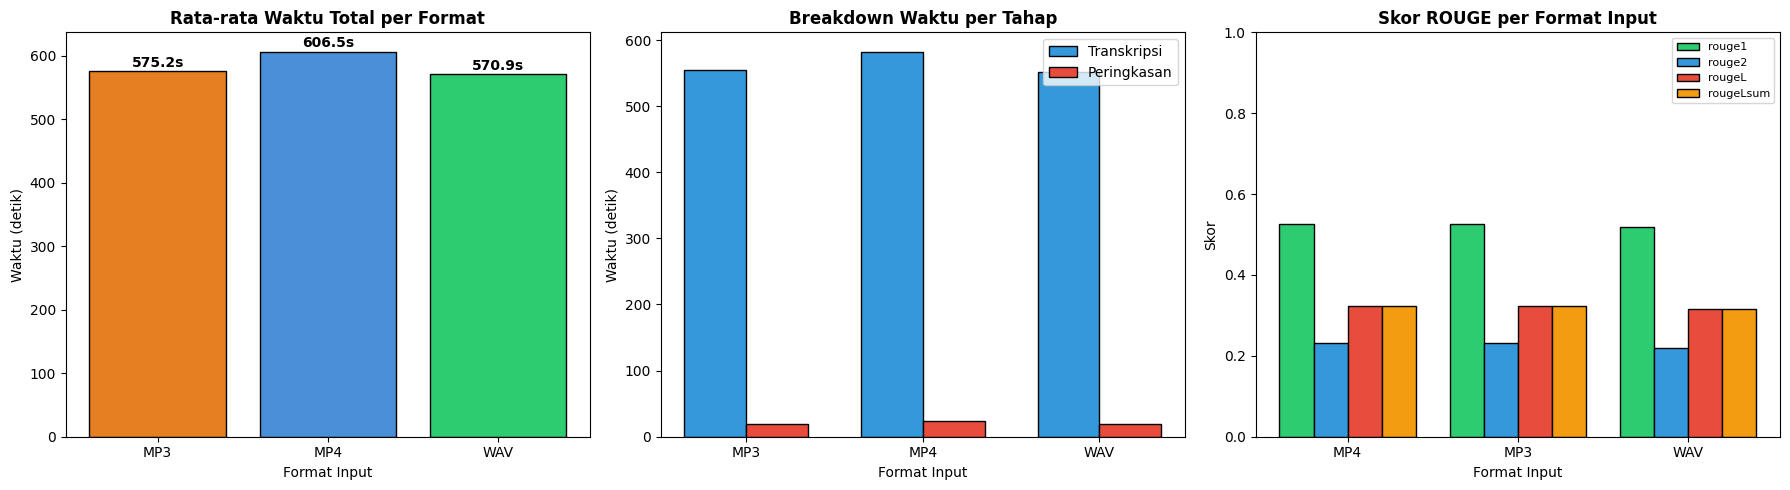

Grafik disimpan ke dataset/end_to_end_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'MP4': '#4A90D9', 'MP3': '#E67E22', 'WAV': '#2ECC71'}

# ── Grafik 1: Rata-rata Waktu Total per Format ──
ax1 = axes[0]
avg_total = df_hasil.groupby('format')['waktu_total'].mean()
bars1 = ax1.bar(avg_total.index, avg_total.values, 
                color=[colors[f] for f in avg_total.index], edgecolor='black')
ax1.set_title('Rata-rata Waktu Total per Format', fontsize=12, fontweight='bold')
ax1.set_ylabel('Waktu (detik)')
ax1.set_xlabel('Format Input')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}s',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Grafik 2: Breakdown Waktu per Tahap ──
ax2 = axes[1]
tahap_cols = ['waktu_transkripsi', 'waktu_ringkasan']
df_breakdown = df_hasil.groupby('format')[tahap_cols].mean()

x_pos = range(len(df_breakdown.index))
width = 0.35
bars_t = ax2.bar([p - width/2 for p in x_pos], df_breakdown['waktu_transkripsi'], 
                  width, label='Transkripsi', color='#3498DB', edgecolor='black')
bars_s = ax2.bar([p + width/2 for p in x_pos], df_breakdown['waktu_ringkasan'],
                  width, label='Peringkasan', color='#E74C3C', edgecolor='black')
ax2.set_title('Breakdown Waktu per Tahap', fontsize=12, fontweight='bold')
ax2.set_ylabel('Waktu (detik)')
ax2.set_xlabel('Format Input')
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(df_breakdown.index)
ax2.legend()

# ── Grafik 3: Skor ROUGE per Format ──
ax3 = axes[2]
if len(df_rouge) > 0:
    rouge_metrics = [c for c in df_rouge.columns if c != 'Format']
    x_pos3 = range(len(df_rouge))
    n_metrics = len(rouge_metrics)
    w = 0.8 / n_metrics
    
    metric_colors = ['#2ECC71', '#3498DB', '#E74C3C', '#F39C12']
    for i, metric in enumerate(rouge_metrics):
        offset = (i - n_metrics/2 + 0.5) * w
        bars_r = ax3.bar([p + offset for p in x_pos3], df_rouge[metric],
                         w, label=metric, color=metric_colors[i % len(metric_colors)],
                         edgecolor='black')
    
    ax3.set_title('Skor ROUGE per Format Input', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Skor')
    ax3.set_xlabel('Format Input')
    ax3.set_xticks(list(x_pos3))
    ax3.set_xticklabels(df_rouge['Format'])
    ax3.legend(fontsize=8)
    ax3.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('dataset/end_to_end_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan ke dataset/end_to_end_comparison.png")

## 8. Perbandingan Konsistensi Output Antar Format

Cek apakah hasil transkripsi dan ringkasan konsisten meskipun format input berbeda.

In [10]:
# Bandingkan konsistensi antar format untuk file yang sama
rouge_konsistensi = evaluate.load('rouge')

print("KONSISTENSI TRANSKRIPSI ANTAR FORMAT")
print("=" * 60)

for name in SAMPLE_FILES:
    hasil_file = {h['format']: h for h in semua_hasil if h['file'] == name}
    formats_tersedia = list(hasil_file.keys())
    
    if len(formats_tersedia) < 2:
        continue
    
    print(f"\nFile {name}:")
    
    # Bandingkan transkripsi WAV vs format lain (WAV sebagai baseline)
    if 'WAV' in hasil_file:
        baseline = hasil_file['WAV']['teks_transkrip']
        for fmt in ['MP4', 'MP3']:
            if fmt in hasil_file:
                other = hasil_file[fmt]['teks_transkrip']
                score = rouge_konsistensi.compute(
                    predictions=[other], references=[baseline]
                )
                print(f"  WAV vs {fmt} (transkripsi): "
                      f"ROUGE-1={score['rouge1']:.4f} | "
                      f"ROUGE-L={score['rougeL']:.4f}")
    
    # Bandingkan ringkasan
    if 'WAV' in hasil_file:
        baseline_ring = hasil_file['WAV']['ringkasan']
        for fmt in ['MP4', 'MP3']:
            if fmt in hasil_file:
                other_ring = hasil_file[fmt]['ringkasan']
                score_ring = rouge_konsistensi.compute(
                    predictions=[other_ring], references=[baseline_ring]
                )
                print(f"  WAV vs {fmt} (ringkasan) : "
                      f"ROUGE-1={score_ring['rouge1']:.4f} | "
                      f"ROUGE-L={score_ring['rougeL']:.4f}")

KONSISTENSI TRANSKRIPSI ANTAR FORMAT

File Paripurna_Ke_20_Persidangan_IV_2024_2025:
  WAV vs MP4 (transkripsi): ROUGE-1=0.9911 | ROUGE-L=0.9911
  WAV vs MP3 (transkripsi): ROUGE-1=0.9897 | ROUGE-L=0.9897
  WAV vs MP4 (ringkasan) : ROUGE-1=0.8727 | ROUGE-L=0.7855
  WAV vs MP3 (ringkasan) : ROUGE-1=0.8727 | ROUGE-L=0.7855


## 9. Ringkasan Hasil Pengujian

In [11]:
print("\n" + "=" * 60)
print("  RINGKASAN PENGUJIAN END-TO-END")
print("=" * 60)

print(f"\nJumlah file diuji  : {len(SAMPLE_FILES)}")
print(f"Format diuji       : {', '.join(FORMAT_MAP.keys())}")
print(f"Total pengujian    : {len(semua_hasil)}")

# Waktu rata-rata
print(f"\nRATA-RATA WAKTU (detik):")
print("-" * 50)
for fmt in FORMAT_MAP.keys():
    data_fmt = [h for h in semua_hasil if h['format'] == fmt]
    if data_fmt:
        avg_transkrip = sum(h['waktu_transkripsi'] for h in data_fmt) / len(data_fmt)
        avg_filter = sum(h['waktu_filter'] for h in data_fmt) / len(data_fmt)
        avg_ringkas = sum(h['waktu_ringkasan'] for h in data_fmt) / len(data_fmt)
        avg_total = sum(h['waktu_total'] for h in data_fmt) / len(data_fmt)
        print(f"  {fmt}: Transkripsi={avg_transkrip:.1f}s | "
              f"Filter={avg_filter:.4f}s | "
              f"Ringkasan={avg_ringkas:.1f}s | "
              f"Total={avg_total:.1f}s")

# ROUGE
print(f"\nSKOR ROUGE:")
print("-" * 50)
for fmt, scores in rouge_per_format.items():
    r1 = scores.get('rouge1', 0)
    r2 = scores.get('rouge2', 0)
    rl = scores.get('rougeL', 0)
    print(f"  {fmt}: ROUGE-1={r1:.4f} | ROUGE-2={r2:.4f} | ROUGE-L={rl:.4f}")

print(f"\n{'='*60}")
print("  Pipeline: Input → Whisper → Filter Kata → IndoT5 → Output")
print(f"{'='*60}")


  RINGKASAN PENGUJIAN END-TO-END

Jumlah file diuji  : 1
Format diuji       : MP4, MP3, WAV
Total pengujian    : 3

RATA-RATA WAKTU (detik):
--------------------------------------------------
  MP4: Transkripsi=582.5s | Filter=0.0023s | Ringkasan=24.0s | Total=606.5s
  MP3: Transkripsi=555.2s | Filter=0.0008s | Ringkasan=20.0s | Total=575.2s
  WAV: Transkripsi=552.2s | Filter=0.0013s | Ringkasan=18.7s | Total=570.9s

SKOR ROUGE:
--------------------------------------------------
  MP4: ROUGE-1=0.5270 | ROUGE-2=0.2313 | ROUGE-L=0.3243
  MP3: ROUGE-1=0.5270 | ROUGE-2=0.2313 | ROUGE-L=0.3243
  WAV: ROUGE-1=0.5193 | ROUGE-2=0.2191 | ROUGE-L=0.3158

  Pipeline: Input → Whisper → Filter Kata → IndoT5 → Output


## 10. Simpan Hasil ke CSV

In [13]:
# Simpan hasil detail
kolom_simpan = ['file', 'format', 'waktu_transkripsi', 'waktu_filter',
                'waktu_ringkasan', 'waktu_total', 'jumlah_kata_transkrip',
                'jumlah_kata_bersih', 'jumlah_kata_ringkasan',
                'teks_transkrip', 'teks_bersih', 'ringkasan']
df_simpan = df_hasil[kolom_simpan]
df_simpan.to_csv('dataset/hasil_end_to_end_test.csv', index=False, encoding='utf-8')

# Simpan skor ROUGE
df_rouge.to_csv('dataset/rouge_per_format.csv', index=False, encoding='utf-8')

print("Hasil berhasil tersimpan!:")
print("  dataset/hasil_end_to_end_test.csv")
print("  dataset/rouge_per_format.csv")
print("  dataset/end_to_end_comparison.png")

Hasil berhasil tersimpan!:
  dataset/hasil_end_to_end_test.csv
  dataset/rouge_per_format.csv
  dataset/end_to_end_comparison.png
